# Experiment 4: Layered Tissue Model
**Drug Modeled:** Lidocaine  
**Condition Tested:** Diffusion through heterogeneous two-layer tissue  
**Research Question:** How do tissue layer boundaries affect Lidocaine 
concentration profiles and drug delivery to deeper tissue?

## Background

Real biological tissue is not uniform. Transdermal Lidocaine delivery 
crosses at minimum two distinct tissue layers:

**Layer 1 — Epidermis/membrane (0 to 0.047cm)**  
The validated membrane from the University of Minnesota study. Dense, 
structured tissue with the baseline literature D value.

**Layer 2 — Deeper soft tissue (0.047cm to 0.15cm)**  
Looser connective tissue beneath the membrane. Less structured, 
meaning drug diffuses more freely — modeled here with a higher D value.

At the boundary between layers, the concentration profile is continuous 
but the rate of diffusion changes abruptly. This discontinuity in 
diffusion rate creates a characteristic change in the slope of the 
concentration profile at the tissue boundary — a feature that cannot 
be captured by a single-layer model.

This experiment implements a piecewise diffusion model: each layer uses 
its own validated D value, and the concentration is computed separately 
for each region.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

# ── Parameters ────────────────────────────────────────────────────────────────

# Layer 1 — Epidermis/membrane
# Source: University of Minnesota, NIH
D1 = 1.25e-8             # cm²/s — validated literature value
layer1_end = 0.047       # cm — validated membrane thickness (473 microns)

# Layer 2 — Deeper soft tissue
# More permeable than membrane — modeled as 3x baseline D
D2 = D1 * 3              # cm²/s

# Initial surface concentration — 2% Lidocaine solution
C0 = 20.0                # mg/mL

# Tissue depth ranges — one array per layer
x1 = np.linspace(0, layer1_end, 500)           # cm — Layer 1
x2 = np.linspace(layer1_end, 0.15, 500)        # cm — Layer 2

# Time point — 10 minutes after administration
t = 600                  # seconds

In [5]:
# ── Piecewise Diffusion Model ─────────────────────────────────────────────────

# Scale factor — keeps peak at C0 for interpretability
# We normalize so surface concentration equals C0
def diffusion_profile(x, D, t, C_surface):
    raw = np.exp(-(x**2) / (4 * D * t))
    return C_surface * raw / raw[0]  # normalize peak to C_surface

# Layer 1
C1 = diffusion_profile(x1, D1, t, C0)

# Boundary concentration — end of Layer 1
C_boundary = C1[-1]

# Layer 2 — starts from boundary concentration
x2_shifted = x2 - layer1_end
C2 = diffusion_profile(x2_shifted, D2, t, C_boundary)

# Uniform reference — same approach, single D across full depth
x_uniform = np.linspace(0, 0.15, 1000)
C_uniform = diffusion_profile(x_uniform, D1, t, C0)

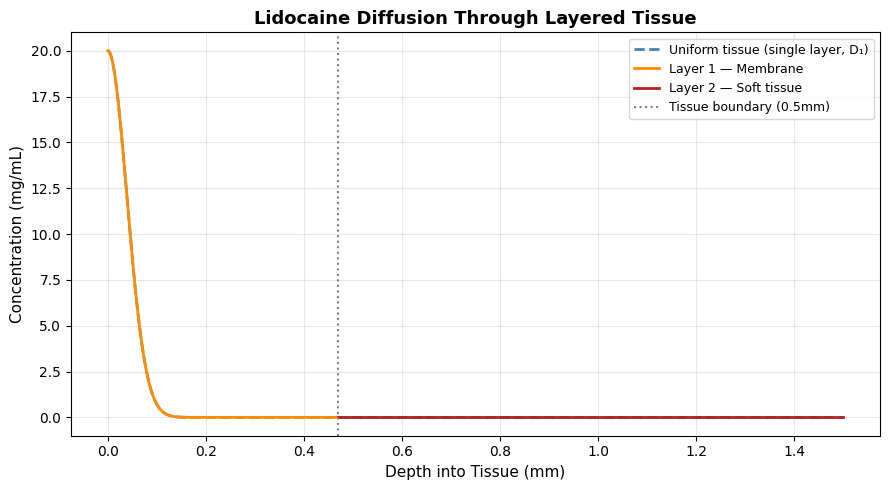

In [6]:
# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

# Uniform single-layer reference
ax.plot(x_uniform * 10, C_uniform, color='steelblue', linewidth=2,
        linestyle='--', label='Uniform tissue (single layer, D₁)')

# Layered model
ax.plot(x1 * 10, C1, color='darkorange', linewidth=2, label='Layer 1 — Membrane')
ax.plot(x2 * 10, C2, color='firebrick', linewidth=2, label='Layer 2 — Soft tissue')

# Mark tissue boundary
ax.axvline(x=layer1_end * 10, color='gray', linestyle=':', linewidth=1.5,
           label=f'Tissue boundary ({layer1_end*10:.1f}mm)')

ax.set_title('Lidocaine Diffusion Through Layered Tissue',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Depth into Tissue (mm)', fontsize=11)
ax.set_ylabel('Concentration (mg/mL)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/exp04_layered.png', dpi=150)
plt.show()

## Observations

- The concentration profile shows a visible change in slope at the tissue 
  boundary — the gradient flattens in Layer 2 due to the higher D value
- Drug penetrates deeper in the layered model compared to uniform tissue 
  at the same time point — the more permeable Layer 2 allows faster spread
- The boundary creates a discontinuity in diffusion rate while maintaining 
  concentration continuity — concentration is equal on both sides of the 
  boundary but the rate of change differs
- The uniform single-layer model underestimates penetration depth into 
  deeper tissue, highlighting the importance of accounting for tissue 
  heterogeneity

## Interpretation

The layered tissue model reveals a clinically important finding: drug 
delivery to deeper tissue is meaningfully affected by the properties of 
the overlying layers. A dense surface layer — such as scar tissue or 
thickened epidermis — acts as a barrier that limits how much Lidocaine 
reaches deeper tissue regardless of how permeable the underlying tissue is.

Conversely, once drug crosses a dense surface layer into more permeable 
deeper tissue, it spreads more rapidly than a uniform model would predict. 
This has implications for onset time — anesthesia may take longer to 
initiate but spread more quickly once the membrane barrier is crossed.

Single-layer diffusion models systematically misrepresent drug delivery 
in heterogeneous tissue, underscoring the need for layered computational 
approaches in pharmacokinetic modeling.

## Next Experiment

Experiments 1 through 4 model Lidocaine diffusion purely as a physical 
process. In reality, as Lidocaine diffuses through tissue it simultaneously 
binds to alpha-1-acid glycoprotein (AAG) — a plasma protein that sequesters 
free drug and removes it from the diffusing pool. Experiment 5 introduces 
reversible binding kinetics via a coupled PDE system to model this 
biochemical interaction.